# Week 2 — Fast Pipelines

## Task 1: DIY Loss Scaling

Код в `task1/train.py`. U-Net на Carvana, AMP (float16).

**StaticScaler** — фиксированный множитель 2^10. `scale()` умножает loss, `step()` делит градиенты обратно и делает `optimizer.step()`.

**DynamicScaler** — начинает с 2^16. Если в градиентах inf/nan — пропускает шаг и уменьшает множитель вдвое. После 2000 успешных шагов подряд — увеличивает вдвое.

In [ ]:
!python -m pip install -r requirements.txt

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [4]:
import subprocess, sys
# Запуск 1: AMP без скейлера (baseline для сравнения)
result = subprocess.run(
    [sys.executable, "train.py", "none"],
    cwd="task1",
    capture_output=False,
    text=True,
)
print("Return code:", result.returncode)

Training without scaler (AMP only)
Epoch 1/5


  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 2/5


Loss: 0.6363 Accuracy: 91.874: 100%|██████████| 40/40 [00:37<00:00,  1.07it/s] 


Epoch 3/5


...

Epoch 4/5


  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 5/5


Loss: 0.6811 Accuracy: 87.4012: 100%|██████████| 40/40 [00:36<00:00,  1.08it/s]


Return code: 0


In [5]:
import subprocess, sys

# Запуск 2: StaticScaler
result = subprocess.run(
    [sys.executable, "train.py", "static"],
    cwd="task1",
    capture_output=False,
    text=True,
)
print("Return code:", result.returncode)

Training with StaticScaler
Epoch 1/5


Loss: 0.6105 Accuracy: 94.4451: 100%|██████████| 40/40 [00:35<00:00,  1.12it/s]


Epoch 2/5


Loss: 0.5974 Accuracy: 97.2111: 100%|██████████| 40/40 [00:36<00:00,  1.10it/s]


Epoch 3/5


...

Epoch 4/5


Loss: 0.5865 Accuracy: 98.5908: 100%|██████████| 40/40 [00:36<00:00,  1.09it/s]


Epoch 5/5


Loss: 0.5895 Accuracy: 98.9285: 100%|██████████| 40/40 [00:36<00:00,  1.09it/s]


Return code: 0


In [6]:
import subprocess, sys

# Запуск 3: DynamicScaler
result = subprocess.run(
    [sys.executable, "train.py", "dynamic"],
    cwd="task1",
    capture_output=False,
    text=True,
)
print("Return code:", result.returncode)

Training with DynamicScaler
Epoch 1/5


  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 2/5


  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 3/5


...

Epoch 4/5


Loss: 0.5862 Accuracy: 98.5822: 100%|██████████| 40/40 [00:36<00:00,  1.09it/s]


Epoch 5/5


Loss: 0.5842 Accuracy: 98.7744: 100%|██████████| 40/40 [00:37<00:00,  1.08it/s]


Return code: 0


## Task 2: Efficient Batching

Код в `task2/dataset.py`, `task2/run_epoch.py`. WikiText-103, токенизация bert-base-uncased, max_length=640.

1. **BRAIN** — паддинг каждой последовательности до 640 в `__getitem__`
2. **BIG BRAIN** — паддинг в `collate_fn` до max длины в батче
3. **ULTRA BIG BRAIN** — bucket sampler, группирует по длинам (разброс <= k), паддинг минимальный
4. **PACKING** — несколько последовательностей в один бин длины 640 с attention mask по сегментам:
   - basic — жадная конкатенация
   - FFD — First-Fit Decreasing, сортировка по убыванию длины, O(N*M)
   - OBFD — Best-Fit Decreasing через segment tree, O(N log L)

In [2]:
# 15% датасета (~175k строк из 1.165M) для ускорения бенчмарка
DATA_PATH = "task2/wikitext-103-raw-v1/wiki.train.small.raw"

In [3]:
import sys, os
# Добавляем task2 в sys.path, чтобы run_epoch.py мог импортировать dataset и transformer
sys.path.insert(0, os.path.abspath("task2"))

import torch
import pandas as pd
from run_epoch import run_epoch, DataMode

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 32
print(f"Device: {device}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [4]:
results = []

# BRAIN
print("Running BRAIN mode...")
r = run_epoch(DataMode.BRAIN, DATA_PATH, batch_size=batch_size, device=device)
results.append({"mode": "BRAIN (pad to max_length)", **r})
print(f"  done: {r['num_batches']} batches, median={r['median']:.4f}s")

Running BRAIN mode...


Token indices sequence length is longer than the specified maximum sequence length for this model (645 > 512). Running this sequence through the model will result in indexing errors
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning,

  done: 4026 batches, median=0.0287s


In [5]:
# BIG BRAIN
print("Running BIG_BRAIN mode...")
r = run_epoch(DataMode.BIG_BRAIN, DATA_PATH, batch_size=batch_size, device=device)
results.append({"mode": "BIG_BRAIN (pad in collate)", **r})
print(f"  done: {r['num_batches']} batches, median={r['median']:.4f}s")

Running BIG_BRAIN mode...


Token indices sequence length is longer than the specified maximum sequence length for this model (645 > 512). Running this sequence through the model will result in indexing errors
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning,

  done: 4026 batches, median=0.0148s


In [6]:
# ULTRA BIG BRAIN (bucket sampler, k=10)
k_val = 10
print(f"Running ULTRA_BIG_BRAIN mode (k={k_val})...")
r = run_epoch(DataMode.ULTRA_BIG_BRAIN, DATA_PATH, batch_size=batch_size, k=k_val, device=device)
results.append({"mode": f"ULTRA_BIG_BRAIN (k={k_val})", **r})
print(f"  done: {r['num_batches']} batches, median={r['median']:.4f}s")

Running ULTRA_BIG_BRAIN mode (k=10)...


Token indices sequence length is longer than the specified maximum sequence length for this model (645 > 512). Running this sequence through the model will result in indexing errors
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning,

  done: 4054 batches, median=0.0060s


In [7]:
# ULTRA DUPER BIG BRAIN (sequence packing)
for pack_mode in ["basic", "ffd", "obfd"]:
    print(f"Running ULTRA_DUPER_BIG_BRAIN mode ({pack_mode})...")
    r = run_epoch(
        DataMode.ULTRA_DUPER_BIG_BRAIN, DATA_PATH,
        batch_size=batch_size, packing_mode=pack_mode, device=device,
    )
    results.append({"mode": f"PACKING ({pack_mode})", **r})
    print(f"  done: {r['num_batches']} batches, median={r['median']:.4f}s")

Running ULTRA_DUPER_BIG_BRAIN mode (basic)...


Token indices sequence length is longer than the specified maximum sequence length for this model (645 > 512). Running this sequence through the model will result in indexing errors
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning,

  done: 947 batches, median=0.0309s
Running ULTRA_DUPER_BIG_BRAIN mode (ffd)...


Token indices sequence length is longer than the specified maximum sequence length for this model (645 > 512). Running this sequence through the model will result in indexing errors
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning,

  done: 807 batches, median=0.0310s
Running ULTRA_DUPER_BIG_BRAIN mode (obfd)...


Token indices sequence length is longer than the specified maximum sequence length for this model (645 > 512). Running this sequence through the model will result in indexing errors
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning,

  done: 807 batches, median=0.0308s


In [8]:
# Таблица с результатами
df = pd.DataFrame(results)
df["min"] = df["min"].map(lambda x: f"{x:.4f}")
df["max"] = df["max"].map(lambda x: f"{x:.4f}")
df["mean"] = df["mean"].map(lambda x: f"{x:.4f}")
df["median"] = df["median"].map(lambda x: f"{x:.4f}")
df

,mode,min,max,mean,median,num_batches
0,BRAIN (pad to max_length),0.0047,0.0352,0.0288,0.0287,4026
1,BIG_BRAIN (pad in collate),0.0026,0.0285,0.0152,0.0148,4026
2,ULTRA_BIG_BRAIN (k=10),0.0017,0.1320,0.0064,0.0060,4054
3,PACKING (basic),0.0075,0.0359,0.0310,0.0309,947
4,PACKING (ffd),0.0042,0.0346,0.0310,0.0310,807
5,PACKING (obfd),0.0041,0.0355,0.0308,0.0308,807


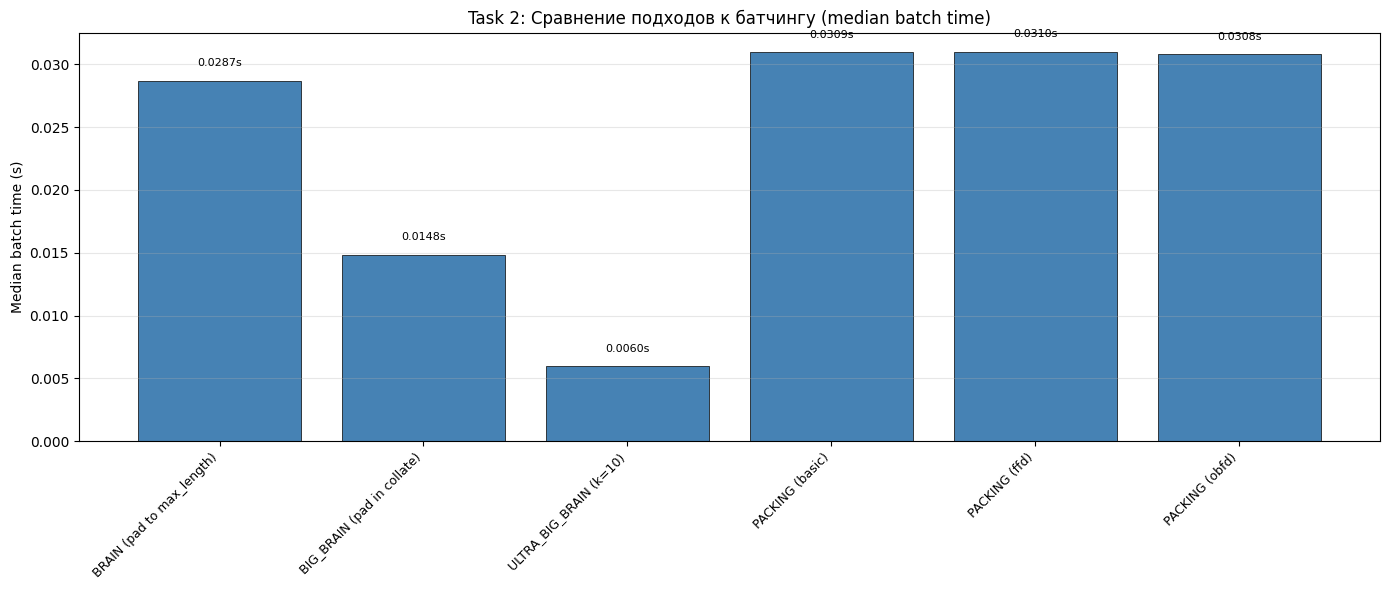

In [9]:
import matplotlib.pyplot as plt

df_plot = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(df_plot))
bars = ax.bar(x, df_plot["median"], color="steelblue", edgecolor="black", linewidth=0.5)

# Подписи значений над столбцами
for bar, val in zip(bars, df_plot["median"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{val:.4f}s", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_plot["mode"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Median batch time (s)")
ax.set_title("Task 2: Сравнение подходов к батчингу (median batch time)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Packing имеет batch time ~0.031s (как BRAIN) — ожидаемо, т.к. каждый бин всегда 640 токенов. Но батчей в 5x меньше (807 vs 4026), потому что в бин упаковано несколько коротких последовательностей. FFD/OBFD на 15% плотнее basic (807 vs 947 батчей). На этом датасете FFD и OBFD дают одинаковый результат, разница только в асимптотике.

ULTRA_BIG_BRAIN — лучший по batch time (0.006s), т.к. bucket sampler минимизирует паддинг. По total epoch time сопоставим с packing.

## Task 3: Профилирование ViT

**Профайлер** (`task3/profiler.py`): контекстный менеджер, вешает forward/backward хуки на все модули. Замеры через `cuda.Event(enable_timing=True)`. Поддерживает расписание (wait/warmup/active), экспорт в Perfetto (`to_perfetto()`) и `summary()`.

Запуск: `cd task3 && python run_epoch.py` — генерирует `trace.json` для Perfetto UI.

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath("task3"))

import torch
import torch.nn as nn
import torch.optim as optim
from run_epoch import get_vit_model, get_loaders, run_epoch_with_profiler, run_epoch
from utils import seed_everything, Settings

Settings.batch_size = 16

seed_everything()
model = get_vit_model()
train_loader, val_loader = get_loaders()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=Settings.lr)

Dataset already extracted
Train Data: 425
Val Data: 106


In [3]:
# Кастомный профайлер: 2 wait + 2 warmup + 10 active steps
run_epoch_with_profiler(model, train_loader, criterion, optimizer, num_steps=10)
print("\ntrace.json сохранён — загрузить в https://ui.perfetto.dev/")

Profiling: 100%|██████████| 14/14 [00:03<00:00,  4.42it/s]

Summary:
  [forward] ViT: ViT: count=10, total=400152.6us, avg=40015.3us
  [forward] transformer: Transformer: count=10, total=380437.5us, avg=38043.8us
  [backward] transformer: Transformer: count=10, total=342254.6us, avg=34225.5us
  [backward] Linear: count=740, total=146818.0us, avg=198.4us
  [forward] Linear: count=740, total=105596.9us, avg=142.7us
  [forward] Dropout: count=490, total=33241.1us, avg=67.8us
  [forward] transformer.layers.2.0: Attention: count=10, total=19457.0us, avg=1945.7us
  [forward] transformer.layers.0.0: Attention: count=10, total=19413.0us, avg=1941.3us
  [backward] transformer.layers.11.0: Attention: count=10, total=18224.1us, avg=1822.4us
  [backward] transformer.layers.6.0: Attention: count=10, total=17446.9us, avg=1744.7us
  [backward] Dropout: count=490, total=17375.2us, avg=35.5us
  [forward] transformer.layers.8.0: Attention: count=10, total=17289.2us, avg=1728.9us
  [forward] transformer.layers.4.0: Attention: count=10, total=17261.6us, avg=1726.2

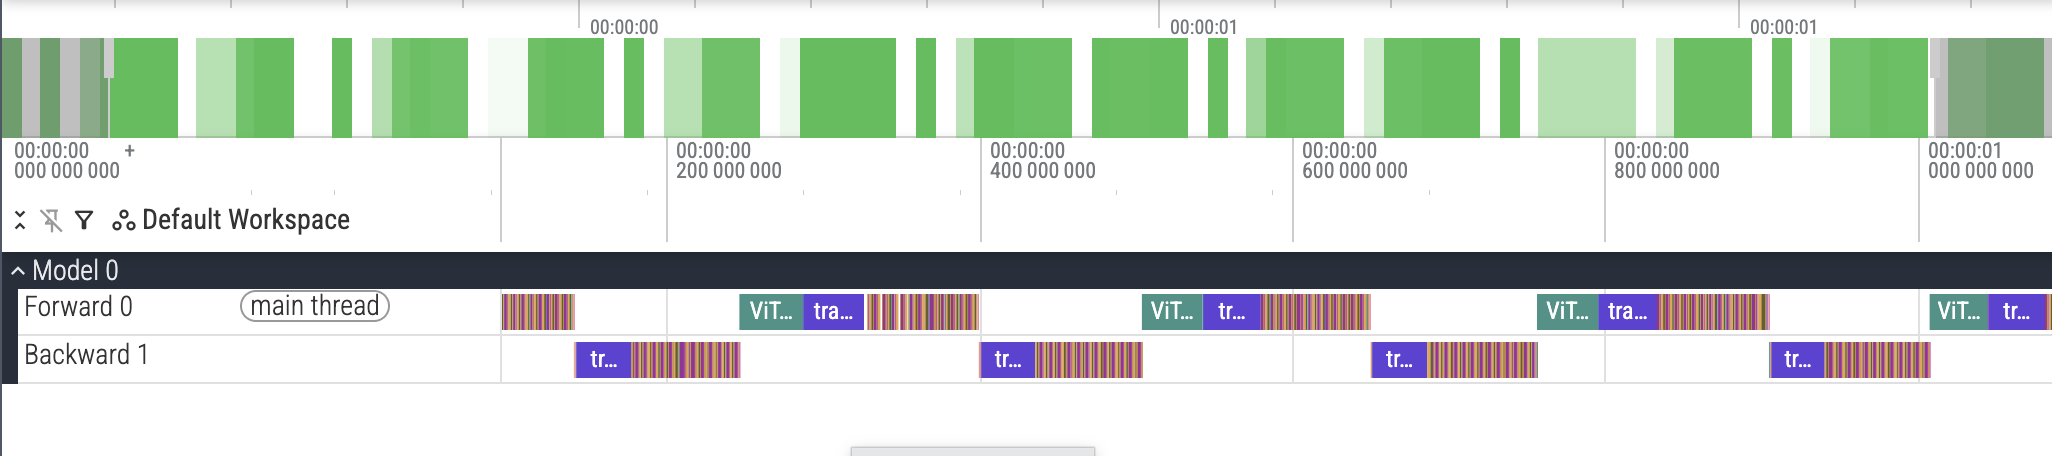

### Найденные неэффективности

| # | Файл | Проблема | Исправление |
|---|------|----------|-------------|
| 1 | `vit.py:95` | `dim=255` — не кратно степени двойки, плохо для tensor cores | `dim=256` |
| 2 | `vit.py:17` | `hidden_dim=255` — аналогично | `hidden_dim=256` |
| 3 | `run_epoch.py:76` | val метрики нормализуются на `len(train_loader)` | `len(val_loader)` |
| 4 | `run_epoch.py:69` | валидация без `torch.no_grad()` — лишний граф и память | обёрнуто в `no_grad()` |
| 5 | `dataset.py:54` | `CenterCrop(224)` перед `RandomResizedCrop(224)` — избыточен | удалён `CenterCrop` |
| 6 | `run_epoch.py:47` | `num_workers=0`, нет `pin_memory` — GPU ждёт CPU | `num_workers=4, pin_memory=True` |

Главный эффект по памяти — `no_grad()` (не хранятся активации). По скорости — `num_workers` (параллельная загрузка) и `dim=256` (tensor cores).

In [4]:
# Сравнение кастомного профайлера с PyTorch profiler
# Оба запускаются с одинаковым schedule: 2 wait + 2 warmup + 10 active
from profiler import Profile
from torch.profiler import profile, ProfilerActivity, schedule
from collections import defaultdict
import pandas as pd

# --- Кастомный профайлер ---
model.train()
custom_schedule = [("wait", 2), ("warmup", 2), ("active", 10)]
optimizer2 = torch.optim.Adam(model.parameters(), lr=Settings.lr)

with Profile(model, name="ViT", schedule=custom_schedule) as prof:
    for i, (data, label) in enumerate(train_loader):
        if i >= 14:
            break
        data = data.to(Settings.device, non_blocking=True)
        label = label.to(Settings.device, non_blocking=True)
        output = model(data)
        loss = nn.CrossEntropyLoss()(output, label)
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()
        prof.step()

# Агрегируем кастомные события по имени слоя
custom_stats = defaultdict(lambda: {"count": 0, "total_us": 0.0})
for ev in prof.events:
    key = ev["name"]
    custom_stats[key]["count"] += 1
    custom_stats[key]["total_us"] += ev["dur"]

# --- PyTorch profiler ---
model.train()
optimizer3 = torch.optim.Adam(model.parameters(), lr=Settings.lr)

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=schedule(wait=2, warmup=2, active=10),
    with_stack=False,
) as pytorch_prof:
    for i, (data, label) in enumerate(train_loader):
        if i >= 14:
            break
        data = data.to(Settings.device, non_blocking=True)
        label = label.to(Settings.device, non_blocking=True)
        output = model(data)
        loss = nn.CrossEntropyLoss()(output, label)
        optimizer3.zero_grad()
        loss.backward()
        optimizer3.step()
        pytorch_prof.step()

# PyTorch profiler top-20 по CUDA time
print("=== PyTorch Profiler (top-20 by CUDA time) ===")
print(pytorch_prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))

# Кастомный profiler top-20 по total time
print("\n=== Custom Profiler (top-20 by total time) ===")
custom_rows = []
for name, s in sorted(custom_stats.items(), key=lambda x: -x[1]["total_us"]):
    avg = s["total_us"] / s["count"] if s["count"] else 0
    custom_rows.append({
        "Layer": name,
        "Calls": s["count"],
        "Total (ms)": f"{s['total_us']/1000:.2f}",
        "Avg (ms)": f"{avg/1000:.3f}",
    })
df_custom = pd.DataFrame(custom_rows[:15])
print(df_custom.to_string(index=False))

=== PyTorch Profiler (top-20 by CUDA time) ===
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     161.469ms       253.73%     161.469ms      16.147ms            10  
                               Optimizer.step#Adam.step         0.00%       0.000us         0.00%       0.000us       0.000us      32.621ms        51.26%      3

Оба профайлера запущены с одинаковым schedule (2 wait, 2 warmup, 10 active).

**Кастомный** — layer-level, через forward/backward хуки + `cuda.Event`. Видим время каждого `nn.Module` целиком (включая все вложенные операции). Например, `Transformer` включает в себя время всех `Attention` и `FeedForward` слоёв.

**PyTorch profiler** — kernel-level, видит отдельные CUDA-операции (`aten::mm`, `aten::bmm`, `aten::copy_`). Не группирует по слоям, зато точнее показывает, какие именно операции тратят GPU-время.

Различия: кастомный профайлер показывает бОльшие абсолютные значения из-за overhead хуков и вложенности (родительский модуль включает время дочерних). PyTorch profiler показывает реальное время ядер без пересечений. Зато кастомный удобнее для поиска bottleneck-слоёв.

In [5]:
epoch_loss, epoch_acc, val_loss, val_acc = run_epoch(model, train_loader, val_loader, criterion, optimizer)
print(f"Train loss: {epoch_loss:.4f}, Train acc: {epoch_acc:.4f}")
print(f"Val loss:   {val_loss:.4f}, Val acc:   {val_acc:.4f}")

Val: 100%|██████████| 7/7 [00:00<00:00, 18.32it/s]

Train loss: 2.9755, Train acc: 0.1250
Val loss:   2.9803, Val acc:   0.1875
